## Data Acquisition & Exploratory Data Analysis

### Setup & Dependencies

In [4]:
# Data Acquisition setup
!pip install ucimlrepo pandas matplotlib seaborn scikit-learn

### Data Acquisition

In [2]:
!pip install ucimlrepo pandas matplotlib seaborn scikit-learn

from ucimlrepo import fetch_ucirepo
import pandas as pd
import os

# Fetch dataset
heart_disease = fetch_ucirepo(id=45)
df = pd.concat([heart_disease.data.features, heart_disease.data.targets], axis=1)

# Define the output directory and file path
output_dir = '../data'
file_path = f'{output_dir}/heart_disease.csv'

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save the DataFrame to a CSV file
df.to_csv(file_path, index=False)

print(f"Data successfully saved to {file_path}")

# Binarize target (0 = no disease, >0 = disease) for clarity in EDA and modeling
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop('num', axis=1)

Data successfully saved to ../data/heart_disease.csv


### Cleaning and Preprocessing

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Missing value analysis
print("Missing Value Analysis:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# Handle missing values
df = df.dropna().reset_index(drop=True)
print("\nMissing values handled. Current dataset shape:", df.shape)

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

output_dir = '../data'
file_path = f'{output_dir}/heart_disease_cleaned.csv'

# Save the DataFrame to a CSV file
df.to_csv(file_path, index=False)

print(f"Data successfully saved to {file_path}")

# Split train/test data properly (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features (fit on train, transform on test to prevent data leakage)
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Preprocessing complete.")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Missing Value Analysis:
ca      4
thal    2
dtype: int64

Missing values handled. Current dataset shape: (297, 14)
Data successfully saved to ../data/heart_disease_cleaned.csv
Preprocessing complete.
X_train shape: (237, 18), X_test shape: (60, 18)


### Exploratory Data Analysis (EDA)

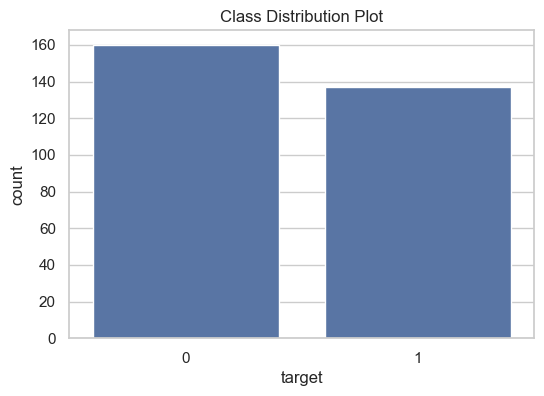

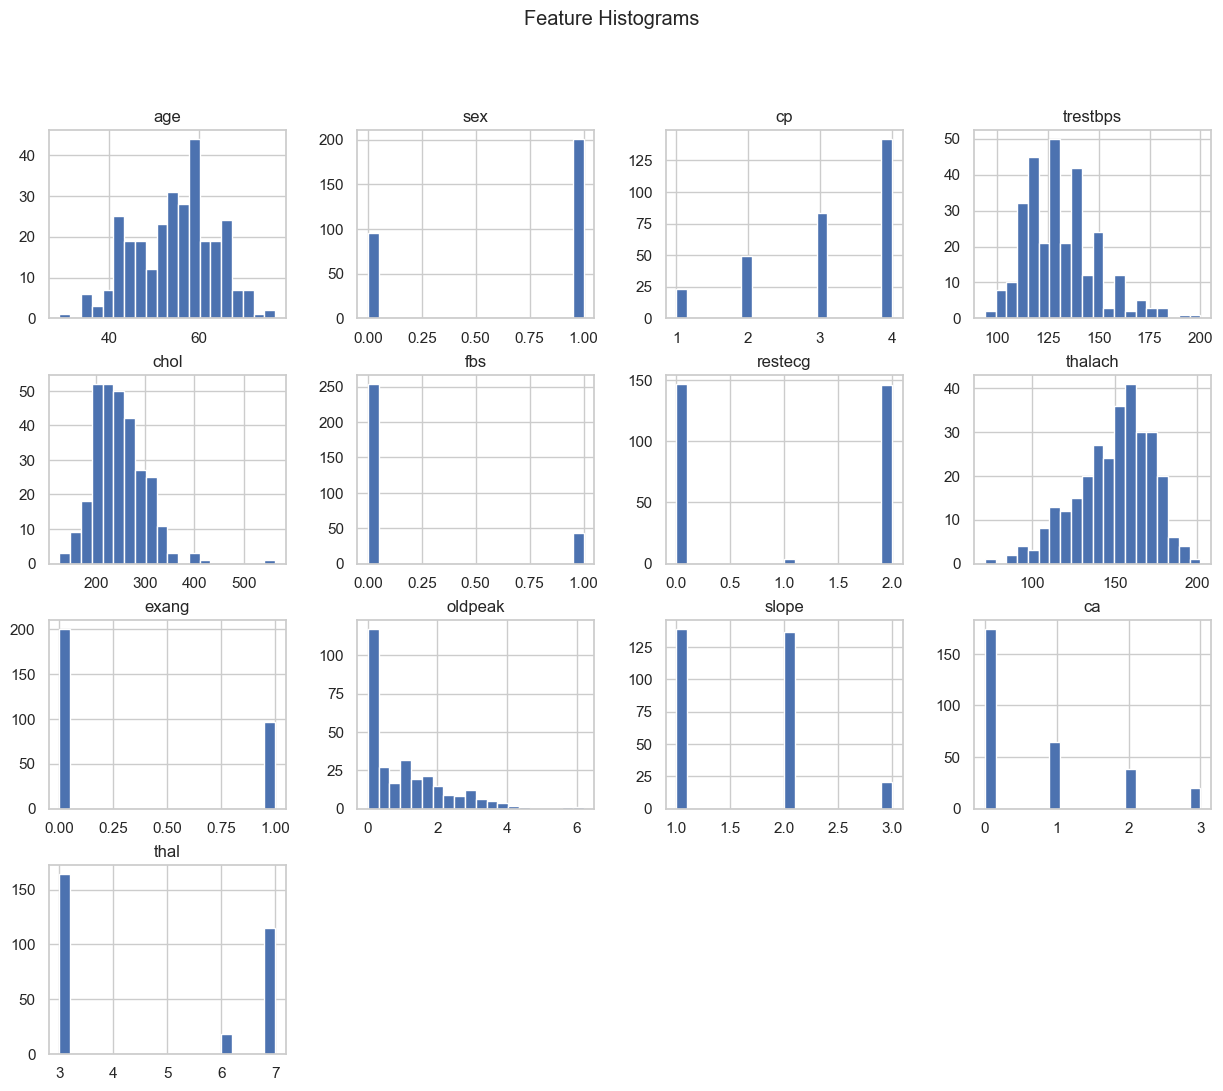

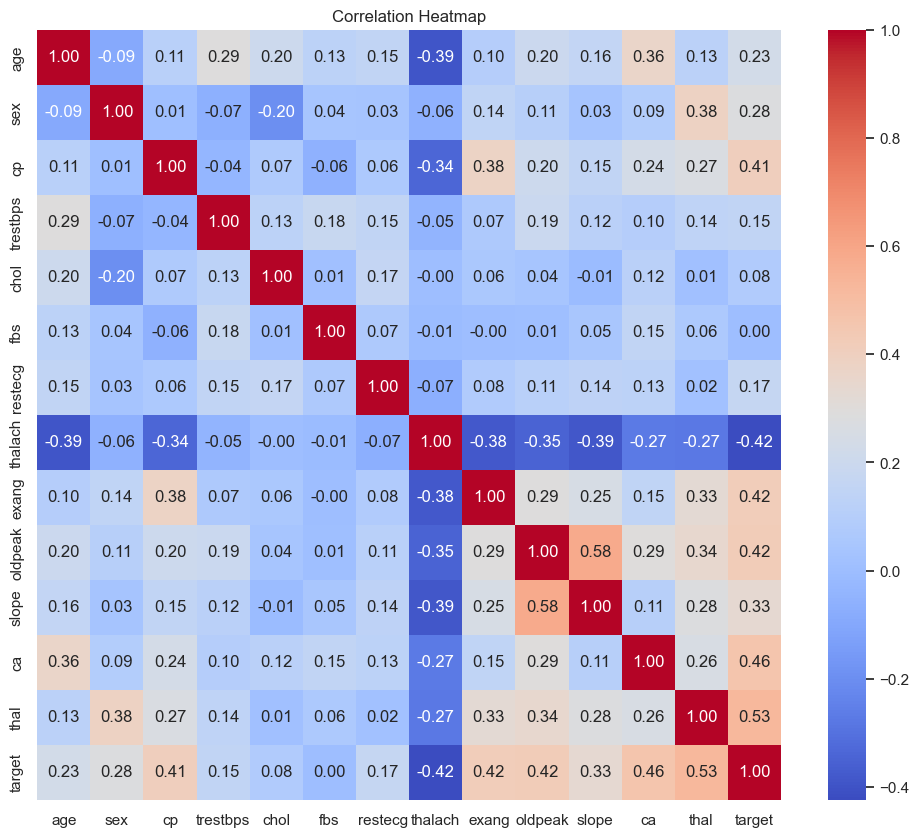

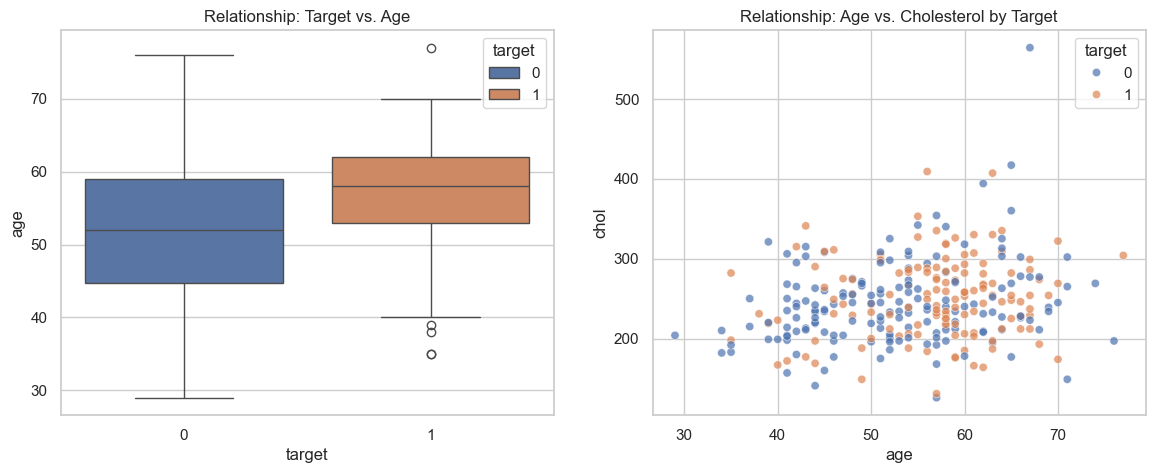

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Class distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title('Class Distribution Plot')
plt.show()

# 2. Histograms
df.drop(columns='target').hist(figsize=(15, 12), bins=20)
plt.suptitle('Feature Histograms')
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 4. Feature relationship analysis (Example: Target vs Age & Cholesterol)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='target', y='age', hue='target', ax=axes[0])
axes[0].set_title('Relationship: Target vs. Age')

sns.scatterplot(data=df, x='age', y='chol', hue='target', alpha=0.7, ax=axes[1])
axes[1].set_title('Relationship: Age vs. Cholesterol by Target')
plt.show()

## Feature Engineering & Model Development

### Setup and Imports for modeling

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

### Model 1 - Logistic Regression with GridSearchCV

In [9]:
# Initialize model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Define hyperparameter grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Perform GridSearchCV
grid_search_lr = GridSearchCV(estimator=log_reg, param_grid=param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_lr.fit(X_train, y_train)

# Best model evaluation
best_lr = grid_search_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Best Parameters:", grid_search_lr.best_params_)
print("5-Fold CV ROC-AUC Score:", grid_search_lr.best_score_)
print("-" * 30)
print("Test Set Metrics [Logistic Regression]:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.4f}")

Logistic Regression Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
5-Fold CV ROC-AUC Score: 0.897888777888778
------------------------------
Test Set Metrics [Logistic Regression]:
Accuracy:  0.8500
Precision: 0.8800
Recall:    0.7857
F1-score:  0.8302
ROC-AUC:   0.9531


### Model 2 - Random Forest with RandomizedSearchCV

In [10]:
# Initialize model
rf_clf = RandomForestClassifier(random_state=42)

# Define hyperparameter distribution
param_dist_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform RandomizedSearchCV
random_search_rf = RandomizedSearchCV(estimator=rf_clf, param_distributions=param_dist_rf,
                                      n_iter=10, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1)
random_search_rf.fit(X_train, y_train)

# Best model evaluation
best_rf = random_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("Random Forest Best Parameters:", random_search_rf.best_params_)
print("5-Fold CV ROC-AUC Score:", random_search_rf.best_score_)
print("-" * 30)
print("Test Set Metrics [Random Forest]:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30}
5-Fold CV ROC-AUC Score: 0.9048731268731268
------------------------------
Test Set Metrics [Random Forest]:
Accuracy:  0.8333
Precision: 0.8750
Recall:    0.7500
F1-score:  0.8077
ROC-AUC:   0.9475


## Experiment Tracking

### MLflow Setup and Imports

In [11]:
!pip install mlflow

import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import os

# Create directory for artifacts if it doesn't exist
os.makedirs("mlflow_artifacts", exist_ok=True)

# Set up MLflow tracking
mlflow.set_tracking_uri("sqlite:///mlruns.db")
mlflow.set_experiment("Heart_Disease_Prediction_Experiment")

<Experiment: artifact_location='file:c:/Users/nnkum/OneDrive/Documents/Assignments/Sem3/MLOPs/heart-disease-prediction/notebooks/mlruns/1', creation_time=1783252731991, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783252731991, lifecycle_stage='active', name='Heart_Disease_Prediction_Experiment', tags={}, trace_location=None, workspace='default'>

### Define MLflow Logging Function

In [12]:
def log_experiment(model_name, model, params, X_test, y_test, y_pred, y_proba):
    with mlflow.start_run(run_name=model_name):
        # Log Model parameters [cite: 61, 62]
        mlflow.log_params(params)
        
        # Log Accuracy metrics [cite: 61, 63]
        mlflow.log_metrics({
            "accuracy": accuracy_score(y_test, y_pred), 
            "precision": precision_score(y_test, y_pred), 
            "recall": recall_score(y_test, y_pred), 
            "f1_score": f1_score(y_test, y_pred), 
            "roc_auc": roc_auc_score(y_test, y_proba)
        })
        
        # Plot and log Confusion matrix [cite: 61, 65]
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        fig_cm, ax_cm = plt.subplots()
        disp.plot(ax=ax_cm, cmap='Blues')
        plt.title(f"{model_name} - Confusion Matrix")
        cm_path = f"mlflow_artifacts/{model_name}_confusion_matrix.png"
        plt.savefig(cm_path)
        mlflow.log_artifact(cm_path)
        plt.close(fig_cm)
        
        # Plot and log ROC curves/plots [cite: 61, 64]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc_val = auc(fpr, tpr)
        fig_roc, ax_roc = plt.subplots()
        ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val:.2f})')
        ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'{model_name} - ROC Curve')
        ax_roc.legend(loc="lower right")
        roc_path = f"mlflow_artifacts/{model_name}_roc_curve.png"
        plt.savefig(roc_path)
        mlflow.log_artifact(roc_path)
        plt.close(fig_roc)
        
        # Log Saved models [cite: 61, 66]
        mlflow.sklearn.log_model(model, artifact_path=f"{model_name}_model")
        
        print(f"Logged {model_name} successfully.")

### Execute Logging for Models

In [13]:
# Log Logistic Regression
log_experiment(
    model_name="Logistic_Regression",
    model=best_lr,
    params=grid_search_lr.best_params_,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred_lr,
    y_proba=y_proba_lr
)

# Log Random Forest
log_experiment(
    model_name="Random_Forest",
    model=best_rf,
    params=random_search_rf.best_params_,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred_rf,
    y_proba=y_proba_rf
)

2026/07/05 17:33:29 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/07/05 17:33:30 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably

Logged Logistic_Regression successfully.


2026/07/05 17:36:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged Random_Forest successfully.


### Start MLflow UI (Run in Notebook)

In [14]:
# Run this cell to start the UI in the background, then open http://localhost:5000 in your browser
import subprocess
process = subprocess.Popen(['mlflow', 'ui', '--backend-store-uri', 'sqlite:///mlruns.db', '--port', '5000'])
print("MLflow UI started on http://localhost:5000")

MLflow UI started on http://localhost:5000


## Model Packaging & Reproducibility 

### Preprocessing Pipeline and Model Serialization

In [15]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

X_raw = df.drop('target', axis=1)
y_raw = df['target']
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=0.1, solver='liblinear', max_iter=1000, random_state=42)) 
])

final_pipeline.fit(X_train_raw, y_train_raw)

joblib.dump(final_pipeline, 'heart_disease_pipeline.pkl')

['heart_disease_pipeline.pkl']

### Generate requirements.txt

In [16]:
requirements = """pandas
scikit-learn
matplotlib
seaborn
mlflow
joblib
ucimlrepo
fastapi
uvicorn
pytest
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

## CI/CD Pipeline & Automated Testing

### Setup Directory and Write Unit Tests (Pytest)

In [17]:
import os

# Create test directory
os.makedirs("tests", exist_ok=True)

# Write the test file
test_code = """
import pytest
import pandas as pd
import joblib
import os

@pytest.fixture
def sample_data():
    # Sample raw data matching the Heart Disease dataset features
    return pd.DataFrame({
        'age': [63, 37],
        'sex': [1, 1],
        'cp': [3, 2],
        'trestbps': [145, 130],
        'chol': [233, 250],
        'fbs': [1, 0],
        'restecg': [0, 1],
        'thalach': [150, 187],
        'exang': [0, 0],
        'oldpeak': [2.3, 3.5],
        'slope': [0, 0],
        'ca': [0, 0],
        'thal': [1, 2]
    })

def test_data_processing(sample_data):
    # Test that there are no missing values in the mock data
    assert sample_data.isnull().sum().sum() == 0
    # Test correct number of columns (13 features)
    assert sample_data.shape[1] == 13

def test_model_inference(sample_data):
    # Check if the model file exists
    model_path = 'heart_disease_pipeline.pkl'
    assert os.path.exists(model_path), f"Model file {model_path} not found."
    
    # Load model and test prediction
    model = joblib.load(model_path)
    predictions = model.predict(sample_data)
    
    # Assertions
    assert len(predictions) == 2
    assert all(p in [0, 1] for p in predictions), "Predictions must be binary (0 or 1)."
"""

with open("tests/test_model.py", "w") as f:
    f.write(test_code)

print("Unit tests written to 'tests/test_model.py'")

Unit tests written to 'tests/test_model.py'


### Create the GitHub Actions CI/CD Pipeline

In [18]:
# Create .github/workflows directory
os.makedirs(".github/workflows", exist_ok=True)

# Write the GitHub Actions YAML file
github_actions_yaml = """
name: MLOps CI/CD Pipeline

on:
  push:
    branches: [ "main" ]
  pull_request:
    branches: [ "main" ]

jobs:
  build-and-test:
    runs-on: ubuntu-latest

    steps:
    - name: Checkout repository
      uses: actions/checkout@v3

    - name: Set up Python 3.10
      uses: actions/setup-python@v4
      with:
        python-version: '3.10'

    - name: Install dependencies
      run: |
        python -m pip install --upgrade pip
        pip install flake8 pytest
        if [ -f requirements.txt ]; then pip install -r requirements.txt; fi

    - name: Code Linting
      run: |
        # Stop the build if there are Python syntax errors or undefined names
        flake8 . --count --select=E9,F63,F7,F82 --show-source --statistics
        # Exit-zero treats all errors as warnings. The GitHub editor is 127 chars wide
        flake8 . --count --exit-zero --max-complexity=10 --max-line-length=127 --statistics

    - name: Run Unit Tests
      run: |
        pytest tests/ --junitxml=reports/test-report.xml

    - name: Upload Test Artifacts
      if: always()
      uses: actions/upload-artifact@v3
      with:
        name: test-reports
        path: reports/test-report.xml
        
    - name: Upload Model Artifact
      uses: actions/upload-artifact@v3
      with:
        name: trained-model
        path: heart_disease_pipeline.pkl
"""

with open(".github/workflows/ci-cd.yml", "w") as f:
    f.write(github_actions_yaml)

print("GitHub Actions pipeline written to '.github/workflows/ci-cd.yml'")

GitHub Actions pipeline written to '.github/workflows/ci-cd.yml'


### Verify Tests Locally (Optional but recommended before pushing)

In [19]:
# Install pytest and flake8 if not already installed, then run the tests
!pip install pytest flake8
!pytest tests/test_model.py -v

============================= test session starts =============================
platform win32 -- Python 3.13.5, pytest-8.3.4, pluggy-1.6.0 -- C:\Users\nnkum\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\nnkum\OneDrive\Documents\Assignments\Sem3\MLOPs\heart-disease-prediction\notebooks
plugins: anyio-4.7.0
collecting ... collected 2 items

tests/test_model.py::test_data_processing PASSED                         [ 50%]
tests/test_model.py::test_model_inference PASSED                         [100%]

============================== warnings summary ===============================
tests/test_model.py::test_model_inference
  C:\Users\nnkum\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6] during transform. These unknown categories will be encoded as all zeros
    warnings.warn(

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
======================== 2 passed, 1 warning in 8.41s

## Model Containerization 

### Write FastAPI Code (app.py)

In [20]:
api_code = """
import logging
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import pandas as pd
import numpy as np
from prometheus_fastapi_instrumentator import Instrumentator
from prometheus_client import Counter, Histogram

# Set up standard API logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s")
logger = logging.getLogger("HeartDiseaseAPI")

app = FastAPI(title="Heart Disease Prediction API with Monitoring")

# Custom Prometheus Metrics for Data Drift and Model Monitoring
PREDICTION_COUNTER = Counter("model_predictions_total", "Total predictions made", ["prediction_result"])
AGE_HISTOGRAM = Histogram("patient_age_distribution", "Distribution of patient ages")
CONFIDENCE_HISTOGRAM = Histogram("model_confidence_score", "Distribution of prediction confidence")

try:
    model = joblib.load("heart_disease_pipeline.pkl")
    logger.info("Model loaded successfully.")
except Exception as e:
    logger.error(f"Failed to load model: {e}")
    raise RuntimeError(f"Failed to load model: {e}")

class PatientData(BaseModel):
    age: float
    sex: int
    cp: int
    trestbps: float
    chol: float
    fbs: int
    restecg: int
    thalach: float
    exang: int
    oldpeak: float
    slope: int
    ca: int
    thal: int

@app.post("/predict")
def predict(data: PatientData):
    logger.info(f"Received prediction request for age: {data.age}, chol: {data.chol}")
    try:
        input_data = pd.DataFrame([data.dict()])
        
        prediction = model.predict(input_data)[0]
        probabilities = model.predict_proba(input_data)[0]
        confidence = np.max(probabilities)
        
        # Log to Prometheus
        PREDICTION_COUNTER.labels(prediction_result=str(prediction)).inc()
        AGE_HISTOGRAM.observe(data.age)
        CONFIDENCE_HISTOGRAM.observe(confidence)
        
        logger.info(f"Prediction: {prediction}, Confidence: {confidence:.2f}")
        
        return {
            "prediction": int(prediction),
            "confidence_score": float(confidence)
        }
    except Exception as e:
        logger.error(f"Prediction failed: {e}")
        raise HTTPException(status_code=400, detail=str(e))

@app.get("/")
def read_root():
    return {"message": "Heart Disease Prediction API is running."}

# Instrument the app to expose standard HTTP metrics
Instrumentator().instrument(app).expose(app)
"""

with open("app.py", "w") as f:
    f.write(api_code)

print("FastAPI application saved to 'app.py'")

FastAPI application saved to 'app.py'


### Write Dockerfile

In [21]:
dockerfile_content = """
# Use official Python runtime as a parent image
FROM python:3.10-slim

# Set the working directory in the container
WORKDIR /app

# Copy the requirements file into the container
COPY requirements.txt .

# Install dependencies
RUN pip install --no-cache-dir -r requirements.txt

# Copy the application code and the trained model
COPY app.py .
COPY heart_disease_pipeline.pkl .

# Expose port 8000 for FastAPI
EXPOSE 8000

# Command to run the application using Uvicorn
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""

with open("Dockerfile", "w") as f:
    f.write(dockerfile_content)

print("Dockerfile created successfully.")

Dockerfile created successfully.


## Production Deployment 

### Enable Kubernetes in Docker Desktop
Before running the deployment scripts, you need to spin up the local cluster:

1. Open the Docker Desktop application interface.

2. Click the Settings (gear icon) in the top-right corner.

3. Select Kubernetes from the left-hand sidebar menu.

4. Check the box that says Enable Kubernetes.

5. Click Apply & restart. It will take a few minutes to download the cluster binaries and start the control plane. 
   You will see a green Kubernetes status icon at the bottom left of Docker Desktop when it is ready.

### Create the Deployment Manifest

In [22]:
deployment_yaml = """
apiVersion: apps/v1
kind: Deployment
metadata:
  name: heart-disease-api-deployment
  labels:
    app: heart-disease-api
spec:
  replicas: 2
  selector:
    matchLabels:
      app: heart-disease-api
  template:
    metadata:
      labels:
        app: heart-disease-api
    spec:
      containers:
      - name: heart-disease-api
        image: heart-disease-api:v1
        imagePullPolicy: IfNotPresent
        ports:
        - containerPort: 8000
"""

with open("deployment.yaml", "w") as f:
    f.write(deployment_yaml)

### Create the Service Manifest

In [23]:
service_yaml = """
apiVersion: v1
kind: Service
metadata:
  name: heart-disease-api-service
spec:
  type: LoadBalancer
  selector:
    app: heart-disease-api
  ports:
  - protocol: TCP
    port: 8080          # The port exposed to your Windows browser
    targetPort: 8000    # The port Uvicorn is listening on inside the container
"""

with open("service.yaml", "w") as f:
    f.write(service_yaml)

print("Kubernetes Service manifest saved to 'service.yaml'")

Kubernetes Service manifest saved to 'service.yaml'


## Monitoring & Logging

### Configure Prometheus

In [24]:
prometheus_yaml = """
global:
  scrape_interval: 5s  # Scrape metrics every 5 seconds

scrape_configs:
  - job_name: 'heart-disease-api'
    static_configs:
      - targets: ['host.docker.internal:8080']
"""

with open("prometheus.yml", "w") as f:
    f.write(prometheus_yaml)

print("Prometheus configuration saved to 'prometheus.yml'")

Prometheus configuration saved to 'prometheus.yml'
